# Diversidade genética

A heterozigosidade é uma medida fundamental da diversidade genética dentro de indivíduos e populações. Ela representa a proporção de loci nos quais um indivíduo possui dois alelos diferentes (heterozigoto), refletindo o nível de variação genética disponível. Essa medida pode ser avaliada de duas formas principais: heterozigosidade observada (Hₒ), calculada diretamente a partir dos genótipos, e heterozigosidade esperada (Hₑ), estimada com base nas frequências alélicas sob o pressuposto de equilíbrio de Hardy-Weinberg.

Existem diferentes formas de analisar a heterozigosidade, dependendo da escala dos dados:

  * Em marcadores específicos (como microssatélites ou SNPs), pode-se calcular Hₒ e Hₑ locus a locus e por população;
  * Com dados genômicos, é comum estimar a heterozigosidade individual genômica, por exemplo, usando a proporção de heterozigotos em um arquivo VCF, ou a densidade de variantes por janela genômica;
  * Em contextos de conservação, pode-se também calcular métricas como F_ROH, baseadas em regiões contínuas de homozigose (ROH), para avaliar níveis de endogamia.

A heterozigosidade tem ampla aplicação em genética de populações e conservação, sendo usada para:

* Avaliar a saúde genética de populações ameaçadas;
* Monitorar efeitos de gargalos populacionais e endogamia;
* Comparar a diversidade genética entre populações ou espécies;
* Informar estratégias de manejo genético e decisões de translocação ou reprodução assistida.

Em suma, a heterozigosidade é um indicador-chave da capacidade adaptativa de populações naturais, sendo essencial para a manutenção da viabilidade evolutiva em longo prazo.

É possível calcular a heterozigosidade através de alguns métodos diferentes. Neste tutorial, usaremos duas estratégias. Para obter a heterozigosidade média, manipularemos o arquivo VCF usando o bcftools. Para explorar a variação da heterozigosidade ao longo do genoma, usaremos o ANGSD e outras ferramentas associadas.



---

## Seção 1: Preparação do ambiente do Google Colab
Para que os tutoriais funcionem de forma adequada é necessário dar acesso ao Google Drive, onde arquivos e scripts estão localizados, bem como a instalação do Conda e dos pacotes que serão utilizados. Esses passos são necessários sempre que ocorrer algum período de inatividade ou começo de nova aula prática.

In [1]:
# Habilitar o acesso ao Google Drive
from google.colab import drive
drive.mount('/content/drive/')

# Criação de uma variável para o diretório base
base_dir = "drive/MyDrive/PopGen_UFMG_2026"

Mounted at /content/drive/


In [2]:
# Instalar Miniconda (1–2 min)
import os

# Add conda to the environment
import os
os.environ['PATH'] = '/usr/local/bin:' + os.environ['PATH']

# Creation of a variable for the base directory
base_dir = "drive/MyDrive/PopGen_UFMG_2026"

miniconda_installer = f"{base_dir}/miniconda/Miniconda3-latest-Linux-x86_64.sh"
if not os.path.exists(miniconda_installer):
    !wget -P "{base_dir}/miniconda" https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh

!bash "{miniconda_installer}" -bfp /usr/local


!conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/main
!conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/r

PREFIX=/usr/local
Unpacking bootstrapper...
Unpacking payload...

Installing base environment...

Preparing transaction: ...working... done
Executing transaction: ...working... done
installation finished.
    You currently have a PYTHONPATH environment variable set. This may cause
    unexpected behavior when running the Python interpreter in Miniconda3.
    For best results, please verify that your PYTHONPATH only points to
    directories of packages that are compatible with the Python interpreter
    in Miniconda3: /usr/local
accepted Terms of Service for https://repo.anaconda.com/pkgs/main
accepted Terms of Service for https://repo.anaconda.com/pkgs/r


In [3]:
# Instalar rpy2
!pip install rpy2

# Ativar o IPython magic
%load_ext rpy2.ipython

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for rpy2-rinterface: filename=rpy2_rinterface-3.6.6-cp313-cp313-linux_x86_64.whl size=140844 sha256=57e3bb4d35914fc78c956bfecedfcf87361209224d822d07b447531364ce8570
  Stored in directory: /root/.cache/pip/wheels/b0/21/4e/3bc241e336e787c947d9c5d2728a5db9f247944ff2a0633aa1
Successfully built rpy2-rinterface
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [rpy2]


In [4]:
# Criação do ambiente Conda e instalação dos programas necessários
!conda create -n divGen -c bioconda -c conda-forge -y bcftools angsd vcftools samtools

Jupyter detected...
2 channel Terms of Service accepted
Retrieving notices: - \ done
Channels:
 - bioconda
 - conda-forge
 - defaults
Platform: linux-64
Solving environment: / - done

## Package Plan ##

  environment location: /usr/local/envs/divGen

  added / updated specs:
    - angsd
    - bcftools
    - samtools
    - vcftools


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    _openmp_mutex-4.5          |           20_gnu          28 KB  conda-forge
    angsd-0.940                |       h13024bc_4         631 KB  bioconda
    bcftools-1.23.1            |       hb2cee57_0         927 KB  bioconda
    bzip2-1.0.8                |       hda65f42_9         254 KB  conda-forge
    c-ares-1.34.6              |       hb03c661_0         203 KB  conda-forge
    ca-certificates-2026.5.20  |       hbd8a1cb_0         127 KB  conda-forge
    gsl-2.7                    |       he838d99_0 

---
## Seção 2: Heterozigosidade média

📝 **Exercícios:**



### 2.1) Calcule a heterozigosidade média por indivíduo

Neste exercício vamos calcular a heterozigosidade média para cada indivíduo presente em um arquivo VCF contendo variantes de 10 preguiças-de-coleira.

A heterozigosidade individual será calculada como:

$$
He = \frac{\text{Número de sítios heterozigotos}}{\text{Número total de pares de bases analisados}}
$$

Neste conjunto de dados, o denominador corresponde ao comprimento total dos scaffolds 14 e 15, que são as regiões genômicas representadas no arquivo VCF.



#### Passo 1: Determinar o tamanho total do genoma analisado

Antes de calcular a heterozigosidade, precisamos saber quantos pares de bases estão representados no VCF.

Podemos extrair essa informação diretamente do cabeçalho do arquivo:

In [29]:
!zcat drive/MyDrive/PopGen_UFMG_2026/Material/vcf/bradypus_chr_14_15.vcf.gz | grep -E 'ID=manual_scaffold_(14|15),' \
| sed -E 's/.*ID=(manual_scaffold_[0-9]+),length=([0-9]+).*/\1\t\2/' | tee /dev/stderr | awk '{s+=$2} END{print "Soma:",s}'

manual_scaffold_14	103095879
manual_scaffold_15	93413383
Soma: 196509262


Portanto, o comprimento total analisado é:

GENOME_LENGTH = 196.509.262 bp

Este valor será utilizado como denominador no cálculo da heterozigosidade de todos os indivíduos.

#### Passo 2: Obter a lista de amostras presentes no VCF

O primeiro passo da análise é extrair os nomes das amostras presentes no arquivo VCF.

In [32]:
!conda run -n divGen bcftools query -l drive/MyDrive/PopGen_UFMG_2026/Material/vcf/bradypus_chr_14_15.vcf.gz

BT04
BT05
BT17
BT19
BTPF17
BTPF22
BTPF26
BTPF27
M184BA
M198RJ


#### Passo 3: Contar o número de sítios heterozigotos por indivíduo

Para cada amostra, utilizamos o `bcftools` para extrair os genótipos e contamos quantas variantes apresentam genótipos heterozigotos.

São considerados heterozigotos:

0/1

1/0

0|1

1|0

Por exemplo, para a amostra BT04:

In [36]:
!conda run -n divGen bcftools view -s BT04 \
drive/MyDrive/PopGen_UFMG_2026/Material/vcf/bradypus_chr_14_15.vcf.gz | grep -v "^#" | grep -oE "0/1|1/0|0\|1|1\|0" | wc -l

15141


Ou seja, BT04 possui 15.141 sítios heterozigotos nos scaffolds 14 e 15.

#### Passo 4: Calcular a heterozigosidade individual

Agora dividimos o número de sítios heterozigotos pelo comprimento total analisado:

Para BT04:

$$
He=\frac{15141}{196509262}
$$

Resultado:

0.0000770

Isso significa que aproximadamente 0,0077% dos pares de bases analisados são heterozigotos nesse indivíduo.

#### Passo 5: Automatizar o cálculo para todas as amostras

O script abaixo realiza automaticamente os passos anteriores para todas as amostras do VCF e gera uma tabela pronta para análises posteriores.

In [24]:
%%bash
VCF="drive/MyDrive/PopGen_UFMG_2026/Material/vcf/bradypus_chr_14_15.vcf.gz"
GENOME_LENGTH="196509262"
OUTPUT="drive/MyDrive/PopGen_UFMG_2026/analyses/04_GeneticDiversity/heterozigosidade.tsv"

# Get sample names from bcftools
SAMPLES=$(conda run -n divGen bcftools query -l "$VCF")

# Write header
echo -e "SampleID\tSitios_Heterozigotos\tHeterozigosidade" > "$OUTPUT"

# Count the number of heterozygous positions with bcftools and calculate heterozygosity
for SAMPLE in $SAMPLES; do
  HETEROZIGOTOS=$(conda run -n divGen bcftools view -s "$SAMPLE" "$VCF" \
                   | grep -v "^#" \
                   | grep -oE "0/1|1/0|0\|1|1\|0" \
                   | wc -l)
  HETEROZIGOSIDADE=$(echo "scale=7; $HETEROZIGOTOS / $GENOME_LENGTH" | bc)
  echo -e "$SAMPLE\t$HETEROZIGOTOS\t$HETEROZIGOSIDADE" >> "$OUTPUT"
done

#### Passo 6: Verificar o arquivo gerado

In [37]:
!cat drive/MyDrive/PopGen_UFMG_2026/analyses/04_GeneticDiversity/heterozigosidade.tsv

SampleID	Sitios_Heterozigotos	Heterozigosidade
BT04	15141	.0000770
BT05	11512	.0000585
BT17	15996	.0000814
BT19	13139	.0000668
BTPF17	37832	.0001925
BTPF22	34097	.0001735
BTPF26	41907	.0002132
BTPF27	27958	.0001422
M184BA	51386	.0002614
M198RJ	17147	.0000872


O arquivo heterozigosidade.tsv contém, para cada indivíduo:

SampleID: identificador da amostra;
Sitios_Heterozigotos: número total de variantes heterozigotas observadas;
Heterozigosidade: proporção de sítios heterozigotos por par de bases analisado.

Este arquivo será utilizado na próxima etapa para a construção de gráficos e comparação dos níveis de diversidade genética entre indivíduos.

### 2.2) Plot os resultados

Primeiramente, vamos criar um novo arquivo chamado `heterozigosidade_pop.tsv` ao qual será adicionada a informação sobre a população de origem do indivíduo. Assim poderemos comparar as heterozigosidades entre indivíduos de diferentes populações. Observe que o comando `awk` abaixo utilizará informação do arquivo `metadata.csv` para adicionar a informação da população como uma nova coluna no arquivo `heterozigosidade.tsv`.

In [38]:
%%bash
OUTPUT="drive/MyDrive/PopGen_UFMG_2026/analyses/04_GeneticDiversity/heterozigosidade.tsv"
POPFILE="drive/MyDrive/PopGen_UFMG_2026/Material/metadata/metadata.csv"
OUTPUT2="drive/MyDrive/PopGen_UFMG_2026/analyses/04_GeneticDiversity/heterozigosidade_pop.tsv"


awk 'NR==FNR { if(FNR>1){ split($0,a,","); pop[a[1]]=a[2] } next } FNR==1 { print $0 "\tPopulacao"; next } { print $0 "\t" pop[$1] }' "$POPFILE" "$OUTPUT" > "$OUTPUT2"

❓ Como ficou o output? Use `cat` para visualizar o arquivo.

In [39]:
!cat drive/MyDrive/PopGen_UFMG_2026/analyses/04_GeneticDiversity/heterozigosidade_pop.tsv

SampleID	Sitios_Heterozigotos	Heterozigosidade	Populacao
BT04	15141	.0000770	South
BT05	11512	.0000585	South
BT17	15996	.0000814	South
BT19	13139	.0000668	South
BTPF17	37832	.0001925	North
BTPF22	34097	.0001735	North
BTPF26	41907	.0002132	North
BTPF27	27958	.0001422	North
M184BA	51386	.0002614	North
M198RJ	17147	.0000872	South


Agora vamos utilizar o script abaixo para gerar um gráfico de boxplot de heterozigosidade, agrupando indivíduos por população.
A biblioteca pandas é usada para carregar os dados a partir do arquivo `heterozigosidade_pop.tsv`. O gráfico é construído com as bibliotecas seaborn e matplotlib, que geram um boxplot para mostrar a distribuição da heterozigosidade em cada população. Sobre o boxplot, pontos individuais são adicionados para representar cada amostra. O gráfico final é salvo em um arquivo .png chamado `heterozigosidade_boxplot_por_populacao.png`.

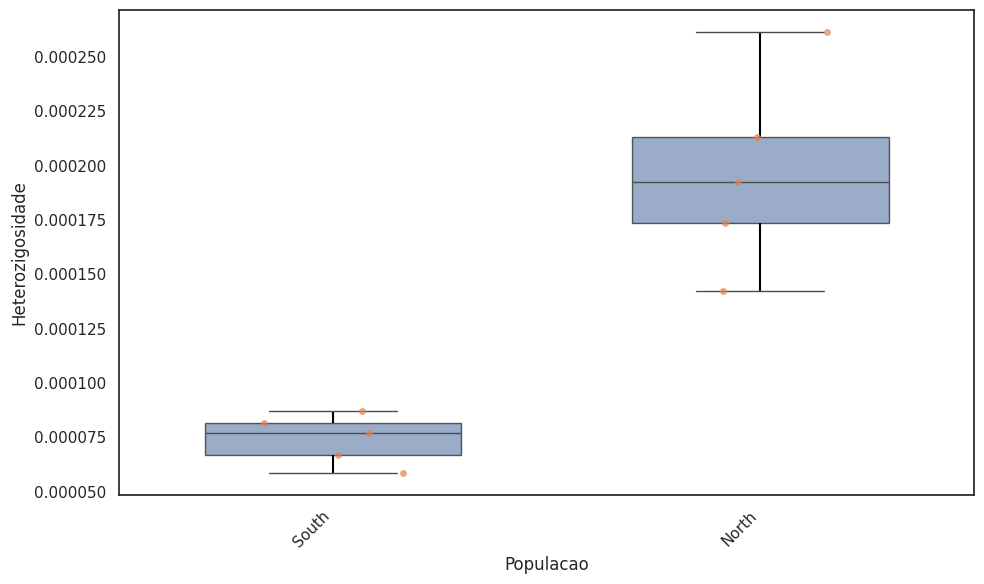

In [40]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Define the input file
INPUT_FILE = "drive/MyDrive/PopGen_UFMG_2026/analyses/04_GeneticDiversity/heterozigosidade_pop.tsv"

# Read in the data
data = pd.read_csv(INPUT_FILE, sep="\t")

# Set plot style
sns.set(style="white")

# Create boxplot with jitter (stripplot) overlay
plt.figure(figsize=(10, 6))
ax = sns.boxplot(data=data, x="Populacao", y="Heterozigosidade",
    width=0.6, showcaps=True, boxprops={'alpha': 0.6, 'edgecolor': 'black'},
    showfliers=False, whiskerprops={'linewidth': 1.5, 'color': 'black'})

sns.stripplot(data=data, x="Populacao", y="Heterozigosidade",
    size=5, jitter=0.2, alpha=0.7, ax=ax)

# Rotate x-axis labels
plt.xticks(rotation=45, ha="right")

# Axis labels and title
plt.xlabel("Populacao")
plt.ylabel("Heterozigosidade")

# Save the plot
plt.tight_layout()
plt.savefig("heterozigosidade_boxplot_por_populacao.png", dpi=300)

# Show the plot
plt.show()

> 🦥❓ Como a diversidade genética das preguiças de coleira da Mata Atlântica Norte se compara à das preguiças da Mata Atlântica Sul?

---

## Seção 3: Heterozigosidade ao longo genoma

Outra forma de avaliar a heterozigosidade é usando uma abordagem baseada em janelas. Essa abordagem permite a visualização da variação da heterozigosidade ao longo do genoma, permitindo focar em regiões de diversidade particularmente alta ou baixa. Ela também permite a comparação dos resultados com outros métodos, como Runs of Homozygosity (RoH). Existem vários softwares que podem realizar essa tarefa de maneira semelhante, incluindo o ANGSD.

O ANGSD (Analysis of Next Generation Sequencing Data) é um software de código aberto projetado para analisar dados de sequenciamento de próxima geração (NGS) de baixa cobertura. Desenvolvido por pesquisadores da Universidade de Copenhague, o ANGSD foi projetado especificamente para lidar com dados de sequenciamento em grande escala, particularmente de organismos não modelo. O ANGSD fornece uma estrutura flexível e eficiente para analisar dados genômicos complexos, permitindo que os pesquisadores realizem vários tipos de análises genéticas e genômicas populacionais.

Os principais recursos do ANGSD incluem:

1.  Identificação de genótipos: o ANGSD pode estimar genotype likelihood a partir de dados de sequenciamento sem realmente identificar genótipos, o que ajuda a reduzir vieses e erros introduzidos por identificações de genótipos difíceis.
2.  Descoberta de SNP: o software pode identificar SNPs e estimar suas frequências alélicas, levando em consideração erros de sequenciamento e níveis variáveis de cobertura de sequenciamento.
3.  Estudos de associação genética: o ANGSD pode realizar Genome-Wide Association Studies (GWAS) e estimar associações genótipo-fenótipo usando modelos lineares mistos ou modelos lineares generalizados.
4.  Estrutura populacional: o ANGSD pode estimar a estrutura populacional e as proporções de mistura usando análise de componentes principais (PCA) ou abordagens baseadas em modelos.
5.  Varreduras de seleção: o software pode detectar sinais de seleção positiva ou balanceadora, usando várias estatísticas como FST, D de Tajima e diversidade nucleotídica.
6.  Manipulação de vários formatos de arquivo: o ANGSD pode trabalhar com vários formatos de arquivo de input, incluindo arquivos BAM, CRAM e VCF, e gerar resultados em vários formatos adequados para análises posteriores.




### 3.1) Calcule a heterozigosidade com o ANGSD

Utilizaremos o sfotware ANGSD para calcular a probabilidade da frequência alélica do sítio (site allele frequency - SAF) com base nas probabilidades genotípicas individuais, assumindo HWE. Ele gera três outputs (angsdput.saf.idx, angsdput.saf.pos.gz e angsdput.saf.gz).
O realSFS executará uma otimização do arquivo .saf, que estimará o Site Frequency Spectrum (SFS) em janelas de um número fixo de bases (200.000 pb). Ele gera um arquivo de saída .est.ml, que manipularemos posteriormente para plotar os resultados.

O script abaixo percorrerá o cromossomo 14 do indivíduo BT04, executando o comando ANGSD e, em seguida, o comando realSFS para cada cromossomo.


In [7]:
%%bash
# Indivíduo BT04 Cromossome 14

reference="drive/MyDrive/PopGen_UFMG_2026/Material/reference/reference_genome_chr_14_15.fasta"
bam="drive/MyDrive/PopGen_UFMG_2026/Material/bam/BT04.bam"
output="drive/MyDrive/PopGen_UFMG_2026/analyses/04_GeneticDiversity/BT04.chr.14"
ml="drive/MyDrive/PopGen_UFMG_2026/analyses/04_GeneticDiversity/BT04.chr.14.est.ml"

conda run -n divGen samtools faidx ${reference}

conda run -n divGen angsd -P 1 -i ${bam} -anc ${reference} -dosaf 1 -gl 1 -C 50 -minQ 20 -minmapq 30 -out ${output} -ref ${reference}

conda run -n divGen realSFS -nsites 200000 ${output}.saf.idx -fold 1 > ${ml}

	-> angsd version: 0.940-dirty (htslib: 1.23.1) build(Dec 15 2024 09:11:59)
	-> angsd -P 1 -i drive/MyDrive/PopGen_UFMG_2026/Material/bam/BT04.bam -anc drive/MyDrive/PopGen_UFMG_2026/Material/reference/reference_genome_chr_14_15.fasta -dosaf 1 -gl 1 -C 50 -minQ 20 -minmapq 30 -out drive/MyDrive/PopGen_UFMG_2026/analyses/04_GeneticDiversity/BT04.chr.14 -ref drive/MyDrive/PopGen_UFMG_2026/Material/reference/reference_genome_chr_14_15.fasta 
	-> Inputtype is BAM/CRAM
[multiReader] 1 samples in 1 input files
	-> Reading fasta: drive/MyDrive/PopGen_UFMG_2026/Material/reference/reference_genome_chr_14_15.fasta
	-> Reading fasta: drive/MyDrive/PopGen_UFMG_2026/Material/reference/reference_genome_chr_14_15.fasta
	-> Parsing 1 number of samples 
	-> Printing at chr: manual_scaffold_14 pos:8848259 chunknumber 100 contains 7205 sites
	-> Printing at chr: manual_scaffold_14 pos:16174055 chunknumber 200 contains 7163 sites
	-> Printing at chr: manual_scaffold_14 pos:24531875 chunknumber 300 contain

---------------------------------------------------------------------------
Certifique-se de que você compreende cada opção na linha de comando do ANGSD:

-   `P <threads>` \- Define o número de threads a serem usados em paralelo.
- `i <input_bam_file>` \- Especifica o arquivo de input como um arquivo BAM.
- `anc <ancestral_fasta_file>` \- Especifica o arquivo de referência fasta ancestral.
- `dosaf <dosaf_value>` \- Calcula o Site Frequency Spectrum (SFS) com base nas genotype likelihoods.
- `gl <método_de_probabilidade_genotípica>` \- Especifica o método usado para calcular as genotype likelihoods.
- `C <base_quality_adjustment>` \- Ajusta o score de qualidade da base por um valor especificado antes de usá-la.
- `minQ <min_base_quality>` \- Define o score mínimo de qualidade da base.
- `minmapq <min_mapping_quality>` \- Define o score mínimo de qualidade de mapeamento.
- `fold <valor_dobrado>` \- Indica se você está analisando SFS folded ou unfolded.
- `out <arquivo_de_saída>` \- Especifica o local e o nome do output.
- `ref <arquivo_fasta_de_referência>` \- Especifica o arquivo fasta de referência.
- `r <região_de_interesse>` \- Especifica a região de interesse. O ANGSD não diferencia os cromossomos se você executar o genoma inteiro de uma só vez, por isso precisamos usar a variável “região” ao executar o ANGSD para especificar o cromossomo/scaffold. Isso será útil para observar a heterozigosidade em todo o genoma.

Além disso, certifique-se de compreender cada opção na linha de comando realSFS:

- `nsites <número_de_locais>` \- Especifica o número de bases a serem considerados para a estimativa.
- `<arquivo_saf_idx_de_entrada>` \- Especifica o arquivo .saf.idx de entrada, que é a saída do programa ANGSD que contém informações sobre o SFS.
- `> <output_est_ml_file>` \- Especifica o local e o nome do output para a estimativa de máxima verossimilhança do SFS.

Agora vamos vizualizar o output principal. Use `cat` e `head` para ver o cabeçalho do arquivo `.est`. Ele apresenta as seguintes colunas:
* 1: Número de sítios monomórficos
* 2: Número de singletons
* 3: 0, já que o SFS é folded.


In [8]:
!cat drive/MyDrive/PopGen_UFMG_2026/analyses/04_GeneticDiversity/BT04.chr.14.est.ml | head

197069.676906 2930.323094 0.000000 
198131.035410 1868.964590 0.000000 
197168.882558 2831.117442 0.000000 
198052.388031 1947.611969 0.000000 
197731.450459 2268.549541 0.000000 
197284.012109 2715.987891 0.000000 
197027.780383 2972.219617 0.000000 
197139.591928 2860.408072 0.000000 
197608.169237 2391.830763 0.000000 
197552.901282 2447.098718 0.000000 


### 3.2) Plot o resultado usando o script abaixo:



Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/viridis_0.6.5.tar.gz'
Content type 'application/x-gzip' length 3047363 bytes (2.9 MB)
downloaded 2.9 MB


The downloaded source packages are in
	‘/tmp/Rtmp2BQMHT/downloaded_packages’


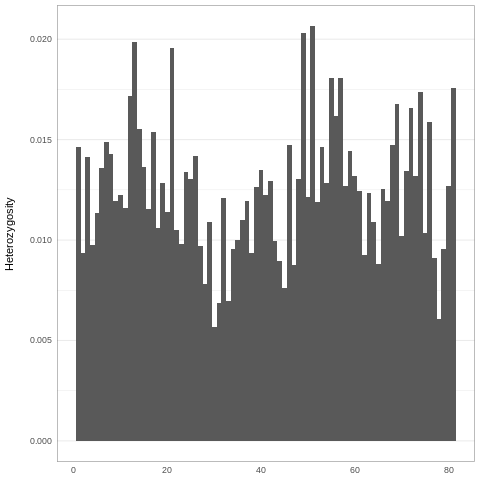

In [17]:
%%R

#install packages
install.packages("viridis")

# Load required libraries
library(dplyr)
library(tidyverse)
library(viridis)
library(scales)

# Read the data
het_master <- read.table("drive/MyDrive/PopGen_UFMG_2026/analyses/04_GeneticDiversity/BT04.chr.14.est.ml",
  header = FALSE, sep = "", fill = TRUE,  quote = "", comment.char = "")

colnames(het_master) <- c("Sites", "Heterozygous", "Extra")

# Data manipulation
het_master <- het_master %>%
  mutate(heterozygosity = Heterozygous / (Sites + Heterozygous)) %>%
  mutate(position = row_number()) %>%
  ungroup()

# Plot all chromosomes
barplot <- ggplot(het_master, aes(x = position, y = heterozygosity)) +
  geom_bar(stat = "identity", width = 1) +
  scale_fill_viridis(discrete = TRUE) +
  labs(x = NULL, y = "Heterozygosity\n") +
  scale_y_continuous(labels = comma) +
  scale_x_continuous(labels = comma) +
  theme_minimal() +
  theme(legend.position = "none",
    strip.text.x = element_text(face = "bold"),
    strip.text.y = element_text(face = "bold"),
    panel.grid.major.x = element_blank(), panel.grid.minor.x = element_blank(),
    panel.spacing.x = unit(0, "line"),  panel.border = element_rect(color = "black", fill = NA, size = 0.25))

print(barplot)
ggsave("drive/MyDrive/PopGen_UFMG_2026/analyses/04_GeneticDiversity/genome_wide_het.png", units = "in", width = 10, height = 5)


> 🦥❓ Como a heterozigosidade está distribuída ao longo do cromossomo? A distribuição é uniforme em todo o cromossomo ou há áreas com heterozigosidade maior ou menor? Há lacunas ou regiões sem heterozigosidade detectável?

---
## Seção 4: SNV Density plot

Agora vamos calcular e visualizar a densidade de SNPs para explorar a diversidade genética em um genoma. As visualizações da densidade de SNP são especialmente úteis para comparar a diversidade genética entre populações ou espécies.







#### 4.1) Prepare o `vcf` para a análise

O script abaixo executa as seguintes etapas:
* Cria um `vcf` para cada indivíduo a partir do `vcf` com múltiplos indivíduos
* Extrai as posições heterozigotas para aquele indivíduo, uma vez que ele pode exibir posições monomórficas vindas do `vcf` com múltiplos indivíduos
* Cria um novo `vcf` para um único indivíduo com apenas posições polimórficas
* Indexa o novo `vcf`

In [41]:
%%bash

#Choose individual
#SAMPLE_NAMES="BT04 BT05 BT17 BT19 M198RJ BTPF17 BTPF22 BTPF26 BTPF27 M184BA"
SAMPLE_NAMES="BT04 BT05 BTPF26 BTPF27"

#Choose the output directory
output_directory="drive/MyDrive/PopGen_UFMG_2026/analyses/04_GeneticDiversity"
VCF_FILE="drive/MyDrive/PopGen_UFMG_2026/Material/vcf/bradypus_chr_14_15.vcf.gz"

# Process each individual
for sample in $SAMPLE_NAMES; do
    echo "Processing sample: $sample"

    # Extract individual's VCF
    conda run -n divGen bcftools view -c 1 -s "$sample" -Oz -o "${output_directory}/${sample}.vcf.gz" "$VCF_FILE"
    conda run -n divGen bcftools index "${output_directory}/${sample}.vcf.gz"

    #Extract heterozygous positions using bcftools query
	  conda run -n divGen bcftools query -f '%CHROM\t%POS\t%REF\t%ALT\t[%GT]\n' "${output_directory}/${sample}.vcf.gz" \
	    | grep -w "0/1" > "${output_directory}/${sample}_hets.txt"

    echo "Heterozygous positions for $sample extracted."

    # Cria arquivo de regiões
    awk '{print $1 "\t" $2}' "${output_directory}/${sample}_hets.txt" > "${output_directory}/${sample}_hets.regions"

    # Usa esse arquivo no bcftools
    conda run -n divGen bcftools view -R "${output_directory}/${sample}_hets.regions" "${output_directory}/${sample}.vcf.gz" \
    -Oz -o "${output_directory}/${sample}_hets.vcf.gz"

    # Indexa o novo VCF
    conda run -n divGen bcftools index "${output_directory}/${sample}_hets.vcf.gz"

    echo "Heterozygous VCF for $sample created."

done

Processing sample: BT04
Heterozygous positions for BT04 extracted.
Heterozygous VCF for BT04 created.
Processing sample: BT05
Heterozygous positions for BT05 extracted.
Heterozygous VCF for BT05 created.
Processing sample: BTPF26
Heterozygous positions for BTPF26 extracted.
Heterozygous VCF for BTPF26 created.
Processing sample: BTPF27
Heterozygous positions for BTPF27 extracted.
Heterozygous VCF for BTPF27 created.


#### 4.2) Calcule a densidade de SNP em janelas do genoma (e.g., 1 Mb)

O script abaixo usa o `vcftools` para calcular o número de SNPs presente em janelas de 1 Mb ao longo do genoma.





In [42]:
%%bash
for file in drive/MyDrive/PopGen_UFMG_2026/analyses/04_GeneticDiversity/*_hets.vcf.gz; do
    name=$(basename "$file" _hets.vcf.gz)
    conda run -n divGen vcftools --gzvcf "$file" --SNPdensity 1000000 --out drive/MyDrive/PopGen_UFMG_2026/analyses/04_GeneticDiversity/"${name}_density"
done


VCFtools - 0.1.17
(C) Adam Auton and Anthony Marcketta 2009

Parameters as interpreted:
	--gzvcf drive/MyDrive/PopGen_UFMG_2026/analyses/04_GeneticDiversity/BT04_hets.vcf.gz
	--out drive/MyDrive/PopGen_UFMG_2026/analyses/04_GeneticDiversity/BT04_density
	--SNPdensity 1000000

Using zlib version: 1.3.1
After filtering, kept 1 out of 1 Individuals
Outputting SNP density
After filtering, kept 12044 out of a possible 12044 Sites
Run Time = 0.00 seconds

VCFtools - 0.1.17
(C) Adam Auton and Anthony Marcketta 2009

Parameters as interpreted:
	--gzvcf drive/MyDrive/PopGen_UFMG_2026/analyses/04_GeneticDiversity/BT05_hets.vcf.gz
	--out drive/MyDrive/PopGen_UFMG_2026/analyses/04_GeneticDiversity/BT05_density
	--SNPdensity 1000000

Using zlib version: 1.3.1
After filtering, kept 1 out of 1 Individuals
Outputting SNP density
After filtering, kept 8620 out of a possible 8620 Sites
Run Time = 0.00 seconds

VCFtools - 0.1.17
(C) Adam Auton and Anthony Marcketta 2009

Parameters as interpreted:
	--gz

Visualize um dos outputs gerados.

In [43]:
!cat drive/MyDrive/PopGen_UFMG_2026/analyses/04_GeneticDiversity/BT04_density.snpden | head

CHROM	BIN_START	SNP_COUNT	VARIANTS/KB
manual_scaffold_14	0	12	0.012
manual_scaffold_14	1000000	34	0.034
manual_scaffold_14	2000000	10	0.01
manual_scaffold_14	3000000	95	0.095
manual_scaffold_14	4000000	72	0.072
manual_scaffold_14	5000000	88	0.088
manual_scaffold_14	6000000	78	0.078
manual_scaffold_14	7000000	69	0.069
manual_scaffold_14	8000000	39	0.039


### 4.3) Prepare o output para gerar um plot

Primeiramente, utilizaremos um comando `awk` para adicionar o nome do indivíduo a cada linha do output.
Em seguida, combinaremos os resultados para todos os indivíduos.

In [44]:
%%bash

# Adicione o nome do indivíduo a cada linha do output
for file in drive/MyDrive/PopGen_UFMG_2026/analyses/04_GeneticDiversity/*_density.snpden; do
    sample=$(basename "$file" _density.snpden)
    awk -v sample="$sample" 'NR==1 {print $0 "\tSample"} NR>1 {print $0 "\t" sample}' "$file" > drive/MyDrive/PopGen_UFMG_2026/analyses/04_GeneticDiversity/"${sample}_annotated.snpden"
done

# Combine os outputs em um único arquivo

tail -q -n +2 drive/MyDrive/PopGen_UFMG_2026/analyses/04_GeneticDiversity/*_annotated.snpden > drive/MyDrive/PopGen_UFMG_2026/analyses/04_GeneticDiversity/combined_snp_density.snpden


Visualize o output para entender o formato do arquivo de entrada da próxima etapa. As colunas mostram: 'CHROM',	'BIN_START', 'SNP_COUNT',	'VARIANTS/KB' e 'sample'.

In [45]:
!cat drive/MyDrive/PopGen_UFMG_2026/analyses/04_GeneticDiversity/combined_snp_density.snpden | head

manual_scaffold_14	0	12	0.012	BT04
manual_scaffold_14	1000000	34	0.034	BT04
manual_scaffold_14	2000000	10	0.01	BT04
manual_scaffold_14	3000000	95	0.095	BT04
manual_scaffold_14	4000000	72	0.072	BT04
manual_scaffold_14	5000000	88	0.088	BT04
manual_scaffold_14	6000000	78	0.078	BT04
manual_scaffold_14	7000000	69	0.069	BT04
manual_scaffold_14	8000000	39	0.039	BT04
manual_scaffold_14	9000000	31	0.031	BT04


### 4.4) Plot os resultados usando o script R abaixo

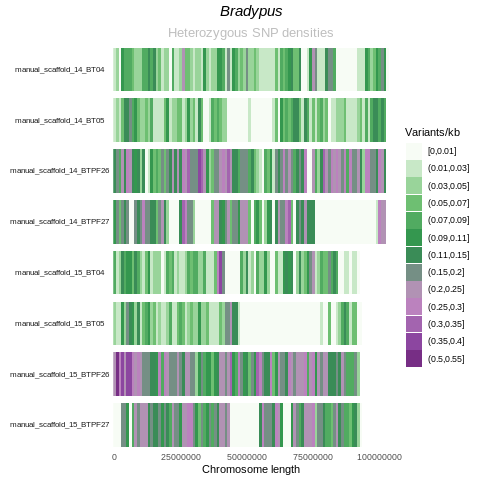

In [10]:
%%R

# Load packages
library(tidyverse)

# Avoid scientific notation
options(scipen = 999)

# Parameters
window_size <- 1000000

target_chromosomes <- c("manual_scaffold_14","manual_scaffold_15")

# Read SNP density file
snpden <- read.table("drive/MyDrive/PopGen_UFMG_2026/analyses/04_GeneticDiversity/combined_snp_density.snpden",
  header = FALSE)

colnames(snpden) <- c("CHROM","BIN_START","SNP_COUNT","VARIANTSperKB","Sample")

# Complete missing windows and prepare data
snpden_complete <- snpden %>%
  mutate(BIN_START = as.numeric(BIN_START)) %>%
  group_by(CHROM) %>%
  complete(BIN_START = seq(0, max(BIN_START), by = window_size)) %>%
  ungroup() %>%
  mutate(SNP_COUNT = replace_na(SNP_COUNT, 0),
    VARIANTSperKB = replace_na(VARIANTSperKB, 0)) %>%
  filter(CHROM %in% target_chromosomes) %>%
  mutate(CHROM = factor(CHROM, levels = target_chromosomes))

# Classify SNP density
snpden_complete$groups <- cut(snpden_complete$VARIANTSperKB,
  breaks = c(0, 0.01, 0.03, 0.05, 0.07, 0.09,
    0.11, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55),
  include.lowest = TRUE)

# Define plot order
plot_order <- c("manual_scaffold_14_BT04","manual_scaffold_14_BT05",
  "manual_scaffold_14_BTPF26","manual_scaffold_14_BTPF27",
  "manual_scaffold_15_BT04","manual_scaffold_15_BT05",
  "manual_scaffold_15_BTPF26","manual_scaffold_15_BTPF27")

snpden_complete <- snpden_complete %>%
  mutate(CHROM_SAMPLE = factor(paste(CHROM, Sample, sep = "_"),
      levels = plot_order))

# Green → purple palette
color_palette <- colorRampPalette(
  c("#F7FCF5", "#74C476", "#238B45", "#C994C7", "#88419D", "#4D004B")
)(length(levels(snpden_complete$groups)))

# Plot
combined_plot <- ggplot(
  snpden_complete,aes(x = BIN_START, y = 1)) +
  geom_tile(aes(fill = groups)) +
  facet_grid(CHROM_SAMPLE ~ ., switch = "y") +
  labs(x = "Chromosome length",
       title = expression(italic("Bradypus")),
       subtitle = "Heterozygous SNP densities") +
  scale_fill_manual(values = color_palette, name = "Variants/kb") +
  scale_x_continuous(expand = c(0, 0)) +
  theme_minimal() +
  theme(axis.title.y = element_blank(), axis.text.y = element_blank(),
    axis.ticks.y = element_blank(), panel.grid = element_blank(),
    strip.text.y.left = element_text(angle = 0, size = 8),
    panel.spacing.y = unit(0.2, "lines"),
    plot.title = element_text(hjust = 0.5, size = 15),
    plot.subtitle = element_text(hjust = 0.5, size = 13,color = "gray"))

# Show plot
print(combined_plot)

# Save figure
ggsave(filename = "bradypus_combined.1Mb.snpden.png",
  plot = combined_plot, dpi = 600, units = "cm",
  width = 15, height = 28, bg = "white",
  path = "drive/MyDrive/PopGen_UFMG_2026/analyses/04_GeneticDiversity"
)


> 🦥❓Avalie a distribuição de SNPs ao longo dos cromossomos 14 e 15 para os indivíduos BT04, BT05, BTPF26 e BTPF27.